# Mechanistic Interpretability: List indexing in Gemma3-4b-pt

This notebook investigates how **Gemma3-4b-pt** determines which number occupies a given position in a list, using **linear probes** on residual stream activations.

## 1. Setup & Installation

In [ ]:
!pip install transformer_lens transformers torch numpy scikit-learn matplotlib seaborn tqdm -q

In [ ]:
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from tqdm.auto import tqdm
from collections import defaultdict
import gc

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

## 2. Load model with TransformerLens

TransformerLens gives us easy hook access to every layer's residual stream.

In [ ]:
from huggingface_hub import login
login()

In [ ]:
import transformer_lens as tl

MODEL_NAME = "google/gemma-3-4b-pt"

print(f"Loading {MODEL_NAME}...")
model = tl.HookedTransformer.from_pretrained(
    MODEL_NAME,
    device=device,
    dtype=torch.bfloat16,
)
model.eval()

print(f"\nModel config:")
print(f"  Layers: {model.cfg.n_layers}")
print(f"  Hidden dim: {model.cfg.d_model}")
print(f"  Heads: {model.cfg.n_heads}")
print(f"  Vocab size: {model.cfg.d_vocab}")

## 3. Dataset Generation

Numbers are sampled randomly for each example.

In [14]:
# ──────────────────────────────────────────────
# Configuration — tweak these as needed
# ──────────────────────────────────────────────
LIST_LENGTH = 6          # Number of elements in each list
NUM_SAMPLES = 600        # Total dataset size
DIGITS = list(range(0, 10))  # Single-digit numbers only

def make_prompt(numbers: list[int], position: int) -> str:
    """Create a prompt styled as a Python interpreter session."""
    list_str = repr(numbers).replace(" ", "")
    return f">>> nums = {list_str}\n>>> nums[{position}]\n"

def generate_dataset(n_samples: int, list_length: int, digits: list[int]):
    """Generate balanced dataset across all positions."""
    samples = []
    samples_per_position = n_samples // list_length

    for pos in range(0, list_length):  # 0-indexed
        for _ in range(samples_per_position):
            numbers = [random.choice(digits) for _ in range(list_length)]
            target = numbers[pos]  # 0-indexed internally
            prompt = make_prompt(numbers, pos)
            samples.append({
                "prompt": prompt,
                "numbers": numbers,
                "position": pos,
                "target": target,
            })

    random.shuffle(samples)
    return samples

dataset = generate_dataset(NUM_SAMPLES, LIST_LENGTH, DIGITS)

print(f"Dataset size: {len(dataset)}")
print(f"Samples per position: {len(dataset) // LIST_LENGTH}")
print(f"\nExample prompts:")
for s in dataset[:3]:
    print(f"  {s['prompt']!r}")
    print(f"    → position={s['position']}, target={s['target']}")

Dataset size: 600
Samples per position: 100

Example prompts:
  '>>> nums = [0,3,3,1,4,6]\n>>> nums[2]\n'
    → position=2, target=3
  '>>> nums = [9,6,4,7,2,6]\n>>> nums[3]\n'
    → position=3, target=7
  '>>> nums = [3,4,0,1,1,4]\n>>> nums[1]\n'
    → position=1, target=4


### 3.1 Verify tokenization

We need to confirm that single digits are single tokens and identify key token positions in our prompt format.

In [15]:
sample = dataset[0]
tokens = model.to_tokens(sample["prompt"], prepend_bos=True)
token_ids = tokens[0].tolist()
str_tokens = [model.tokenizer.decode([t]) for t in token_ids]

print("Token breakdown:")
for i, (tok_id, tok_str) in enumerate(zip(token_ids, str_tokens)):
    print(f"  pos {i:2d}: {tok_id:6d} → {tok_str!r}")

print(f"\nTotal tokens: {len(str_tokens)}")

Token breakdown:
  pos  0:      2 → '<bos>'
  pos  1:  22539 → '>>>'
  pos  2:  27536 → ' nums'
  pos  3:    578 → ' ='
  pos  4:    870 → ' ['
  pos  5: 236771 → '0'
  pos  6: 236764 → ','
  pos  7: 236800 → '3'
  pos  8: 236764 → ','
  pos  9: 236800 → '3'
  pos 10: 236764 → ','
  pos 11: 236770 → '1'
  pos 12: 236764 → ','
  pos 13: 236812 → '4'
  pos 14: 236764 → ','
  pos 15: 236825 → '6'
  pos 16: 236842 → ']'
  pos 17:    107 → '\n'
  pos 18:  22539 → '>>>'
  pos 19:  27536 → ' nums'
  pos 20: 236840 → '['
  pos 21: 236778 → '2'
  pos 22: 236842 → ']'
  pos 23:    107 → '\n'

Total tokens: 24


In [16]:
def find_token_positions(str_tokens: list[str], list_length: int):
    positions = {}

    # Find ALL bracket positions
    bracket_indices = [i for i, t in enumerate(str_tokens) if '[' in t]

    # First '[' starts the list — digits follow at every other token
    if len(bracket_indices) >= 1:
        list_bracket = bracket_indices[0]
        digit_positions = []
        for i in range(list_bracket + 1, len(str_tokens)):
            if ']' in str_tokens[i]:
                break
            if str_tokens[i].strip().isdigit():
                digit_positions.append(i)
        for idx, pos in enumerate(digit_positions):
            positions[f"list_digit_{idx}"] = pos

    # Second '[' is the indexing bracket — the digit after it is the query
    if len(bracket_indices) >= 2:
        index_bracket = bracket_indices[1]
        if index_bracket + 1 < len(str_tokens) and str_tokens[index_bracket + 1].strip().isdigit():
            positions["query_position"] = index_bracket + 1

    positions["last_token"] = len(str_tokens) - 1

    return positions

# Test it
tok_positions = find_token_positions(str_tokens, LIST_LENGTH)
print("Identified token positions:")
for name, idx in sorted(tok_positions.items(), key=lambda x: x[1]):
    print(f"  {name:20s} → pos {idx:2d} → {str_tokens[idx]!r}")

Identified token positions:
  list_digit_0         → pos  5 → '0'
  list_digit_1         → pos  7 → '3'
  list_digit_2         → pos  9 → '3'
  list_digit_3         → pos 11 → '1'
  list_digit_4         → pos 13 → '4'
  list_digit_5         → pos 15 → '6'
  query_position       → pos 21 → '2'
  last_token           → pos 23 → '\n'


## 4. Sanity Check: Does the Model Solve This Task?

Before probing, let's verify that the model actually retrieve positional information from lists.

In [21]:
def evaluate_model_accuracy(dataset, model, n_samples=100):
    """Check how often the model's top prediction matches the target."""
    subset = dataset[:n_samples]
    correct = 0
    results_by_pos = defaultdict(lambda: {"correct": 0, "total": 0})

    for sample in tqdm(subset, desc="Evaluating"):
        tokens = model.to_tokens(sample["prompt"], prepend_bos=True)
        with torch.no_grad():
            logits = model(tokens)

        # Get prediction at last position
        last_logits = logits[0, -1, :]
        pred_token = model.to_string(last_logits.argmax().item())

        target_str = str(sample["target"])
        is_correct = pred_token.strip() == target_str
        correct += is_correct

        pos = sample["position"]
        results_by_pos[pos]["total"] += 1
        results_by_pos[pos]["correct"] += is_correct

    overall_acc = correct / len(subset)
    print(f"\nOverall accuracy: {overall_acc:.1%} ({correct}/{len(subset)})")
    print(f"\nAccuracy by queried position:")
    for pos in sorted(results_by_pos.keys()):
        r = results_by_pos[pos]
        acc = r['correct'] / r['total']
        print(f"  Position {pos}: {acc:.1%} ({r['correct']}/{r['total']})")

    return overall_acc, results_by_pos

overall_acc, pos_results = evaluate_model_accuracy(dataset, model, n_samples=200)

Evaluating:   0%|          | 0/200 [00:00<?, ?it/s]


Overall accuracy: 97.0% (194/200)

Accuracy by queried position:
  Position 0: 100.0% (31/31)
  Position 1: 100.0% (39/39)
  Position 2: 100.0% (32/32)
  Position 3: 93.8% (30/32)
  Position 4: 97.5% (39/40)
  Position 5: 88.5% (23/26)


## 5. Collect Residual Stream Activations

We run each prompt through the model and cache the residual stream at every layer. We'll probe at multiple token positions:
- **Each list digit** (does the model tag digits with their position?)
- **The query position token** (does position info concentrate here?)
- **The last token** (where the model must have assembled the answer)

In [24]:
# Which token positions to probe
TOKEN_POSITIONS_TO_PROBE = [
    "last_token"
]

BATCH_SIZE = 16  # Adjust if OOM

def collect_activations(dataset, model, token_positions_to_probe, batch_size=BATCH_SIZE):
    """
    Collect residual stream activations at all layers for specified token positions.

    Returns:
        activations: dict[str, np.ndarray] — shape (n_samples, n_layers, d_model) per token position
        targets: np.ndarray — shape (n_samples,)
        positions: np.ndarray — shape (n_samples,)
    """
    n_layers = model.cfg.n_layers
    d_model = model.cfg.d_model
    n_samples = len(dataset)

    # Pre-allocate storage
    activations = {
        tok_pos: np.zeros((n_samples, n_layers + 1, d_model), dtype=np.float32)
        for tok_pos in token_positions_to_probe
    }  # n_layers + 1 to include layer 0 (embedding)
    targets = np.zeros(n_samples, dtype=np.int64)
    positions = np.zeros(n_samples, dtype=np.int64)

    for start_idx in tqdm(range(0, n_samples, batch_size), desc="Collecting activations"):
        end_idx = min(start_idx + batch_size, n_samples)
        batch = dataset[start_idx:end_idx]

        prompts = [s["prompt"] for s in batch]
        tokens = model.to_tokens(prompts, prepend_bos=True)

        with torch.no_grad():
            # Run with cache — gets residual stream at every layer
            _, cache = model.run_with_cache(
                tokens,
                names_filter=lambda name: name.endswith("hook_resid_post") or name == "hook_embed",
            )

        for batch_i, sample in enumerate(batch):
            global_i = start_idx + batch_i
            targets[global_i] = sample["target"]
            positions[global_i] = sample["position"]

            # Get token position map for this sample
            token_ids = model.to_tokens(sample["prompt"], prepend_bos=True)[0].tolist()
            s_tokens = [model.tokenizer.decode([t]) for t in token_ids]

            tok_pos_map = find_token_positions(s_tokens, LIST_LENGTH)

            for tok_pos_name in token_positions_to_probe:
                if tok_pos_name not in tok_pos_map:
                    continue
                tok_idx = tok_pos_map[tok_pos_name]

                # Layer 0: embedding
                embed_act = cache["hook_embed"][batch_i, tok_idx, :]
                activations[tok_pos_name][global_i, 0, :] = embed_act.float().cpu().numpy()

                # Layers 1..n_layers: residual stream after each layer
                for layer in range(n_layers):
                    act = cache[f"blocks.{layer}.hook_resid_post"][batch_i, tok_idx, :]
                    activations[tok_pos_name][global_i, layer + 1, :] = act.float().cpu().numpy()

        # Free cache memory
        del cache
        torch.cuda.empty_cache()

    return activations, targets, positions

print(f"Collecting activations for {len(dataset)} samples...")
activations, targets, queried_positions = collect_activations(
    dataset, model, TOKEN_POSITIONS_TO_PROBE
)

print(f"\nActivation shapes:")
for name, arr in activations.items():
    print(f"  {name}: {arr.shape}")
print(f"Targets: {targets.shape}, unique values: {np.unique(targets)}")


Activation shapes:
  last_token: (600, 35, 2560)
Targets: (600,), unique values: [0 1 2 3 4 5 6 7 8 9]


## 6. Train linear probes for each position

For each token position we're probing, how does accuracy vary across layers?

In [27]:
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tqdm.auto import tqdm

# ------------------------------------------------------------------
# 1. Collect activations at the final token
# ------------------------------------------------------------------

def collect_activations_final_token(dataset, model, batch_size=BATCH_SIZE):
    """
    Collect residual stream activations at the final token for all samples.

    Returns:
        activations: np.ndarray — shape (n_samples, n_layers+1, d_model)
        all_digits: np.ndarray — shape (n_samples, list_length), digit at each list position
        queried_positions: np.ndarray — shape (n_samples,), which position was queried
        targets: np.ndarray — shape (n_samples,), the correct answer (= digits[queried_pos])
    """
    n_layers = model.cfg.n_layers
    d_model = model.cfg.d_model
    n_samples = len(dataset)

    activations = np.zeros((n_samples, n_layers + 1, d_model), dtype=np.float32)
    all_digits = np.zeros((n_samples, LIST_LENGTH), dtype=np.int64)
    queried_positions = np.zeros(n_samples, dtype=np.int64)
    targets = np.zeros(n_samples, dtype=np.int64)

    for start_idx in tqdm(range(0, n_samples, batch_size), desc="Collecting activations"):
        end_idx = min(start_idx + batch_size, n_samples)
        batch = dataset[start_idx:end_idx]

        prompts = [s["prompt"] for s in batch]
        tokens = model.to_tokens(prompts, prepend_bos=True)

        with torch.no_grad():
            _, cache = model.run_with_cache(
                tokens,
                names_filter=lambda name: name.endswith("hook_resid_post") or name == "hook_embed",
            )

        for batch_i, sample in enumerate(batch):
            global_i = start_idx + batch_i

            # Store metadata
            all_digits[global_i] = sample["numbers"]
            queried_positions[global_i] = sample["position"]
            targets[global_i] = sample["target"]

            # Find the final token position for this sample
            token_ids = model.to_tokens(sample["prompt"], prepend_bos=True)[0].tolist()
            s_tokens = [model.tokenizer.decode([t]) for t in token_ids]
            tok_pos_map = find_token_positions(s_tokens, LIST_LENGTH)
            final_pos = tok_pos_map["last_token"]

            # Layer 0: embedding
            activations[global_i, 0, :] = cache["hook_embed"][batch_i, final_pos, :].float().cpu().numpy()

            # Layers 1..n_layers
            for layer in range(n_layers):
                act = cache[f"blocks.{layer}.hook_resid_post"][batch_i, final_pos, :]
                activations[global_i, layer + 1, :] = act.float().cpu().numpy()

        del cache
        torch.cuda.empty_cache()

    return activations, all_digits, queried_positions, targets


print(f"Collecting final-token activations for {len(dataset)} samples...")
ft_activations, all_digits, queried_positions, ft_targets = collect_activations_final_token(dataset, model)
print(f"Activations shape: {ft_activations.shape}")
print(f"All digits shape: {all_digits.shape}")


# ------------------------------------------------------------------
# 2. Train probes: one per list position + one for the queried digit
# ------------------------------------------------------------------

def train_positional_probes(activations, all_digits, queried_positions, targets,
                            test_size=0.2, C=1.0, max_iter=1000):
    """
    Train 7 probes at each layer:
      - 6 probes, one per list position, predicting the digit at that position
      - 1 probe predicting the queried (target) digit

    Returns:
        results: dict mapping (probe_name, layer) -> test_acc
    """
    n_samples, n_layers_total, d_model = activations.shape

    # Shared train/test split
    indices = np.arange(n_samples)
    train_idx, test_idx = train_test_split(
        indices, test_size=test_size, random_state=SEED
    )

    results = {}

    for layer in tqdm(range(n_layers_total), desc="Training probes across layers"):
        X = activations[:, layer, :]
        X_train, X_test = X[train_idx], X[test_idx]

        # Standardize
        mean = X_train.mean(axis=0)
        std = X_train.std(axis=0) + 1e-8
        X_train_norm = (X_train - mean) / std
        X_test_norm = (X_test - mean) / std

        # Probe for each list position
        for pos in range(LIST_LENGTH):
            y = all_digits[:, pos]
            y_train, y_test = y[train_idx], y[test_idx]

            probe = LogisticRegression(
                C=C, max_iter=max_iter, solver="lbfgs",
                random_state=SEED, n_jobs=-1,
            )
            probe.fit(X_train_norm, y_train)
            test_acc = accuracy_score(y_test, probe.predict(X_test_norm))
            results[(f"list_pos_{pos}", layer)] = test_acc

        # Probe for the queried (target) digit
        y_train, y_test = targets[train_idx], targets[test_idx]
        probe = LogisticRegression(
            C=C, max_iter=max_iter, solver="lbfgs",
            random_state=SEED, n_jobs=-1,
        )
        probe.fit(X_train_norm, y_train)
        test_acc = accuracy_score(y_test, probe.predict(X_test_norm))
        results[(f"queried_target", layer)] = test_acc

    return results


print("Training positional probes...")
pos_probe_results = train_positional_probes(
    ft_activations, all_digits, queried_positions, ft_targets
)
print(f"Trained {len(pos_probe_results)} probes.")



Activations shape: (600, 35, 2560)
All digits shape: (600, 6)
Training positional probes...


Training probes across layers:   0%|          | 0/35 [00:00<?, ?it/s]

Trained 245 probes.


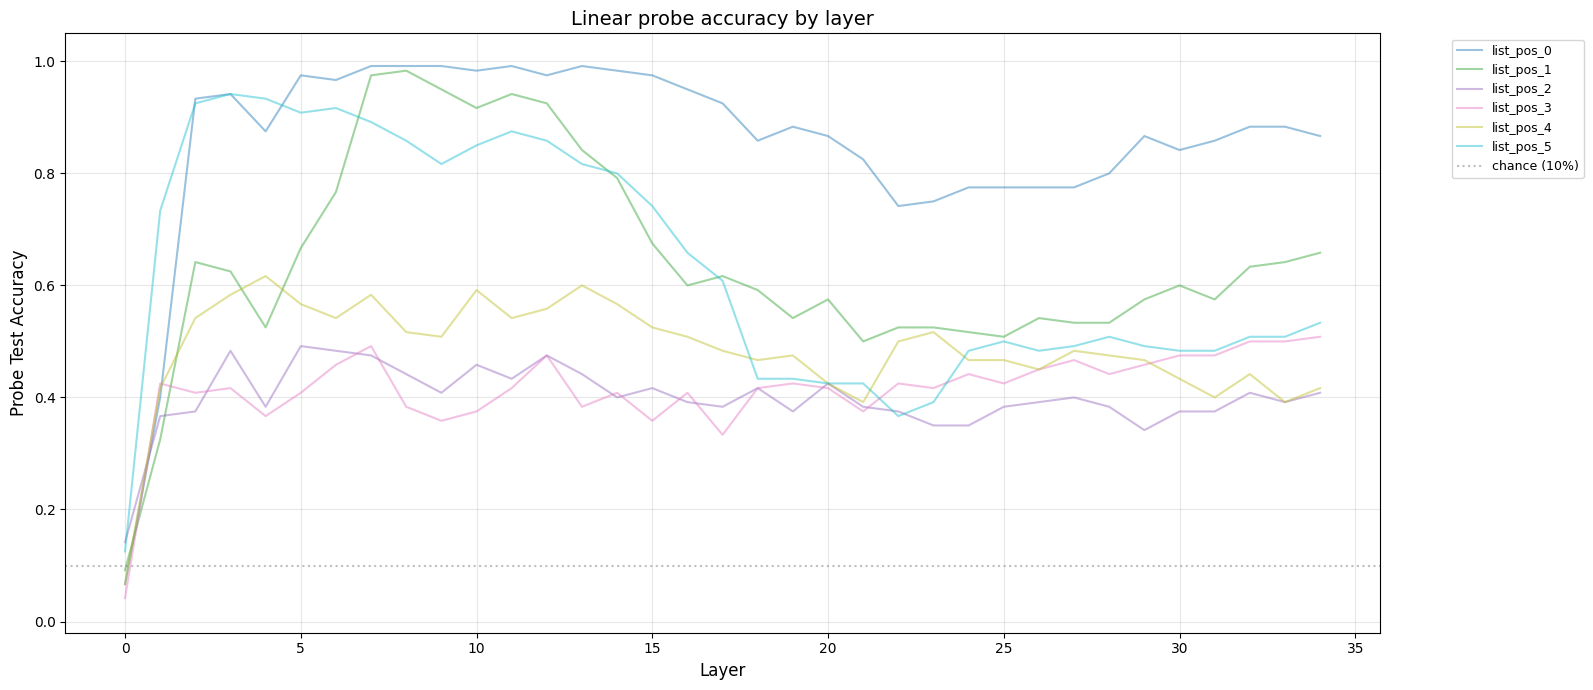

In [46]:
def plot_positional_probes(results, n_layers_total):
    layers = list(range(n_layers_total))

    fig, ax = plt.subplots(figsize=(16, 7))

    # Distinct color for each digit position
    digit_colors = plt.cm.tab10(np.linspace(0, 1, LIST_LENGTH))

    for pos in range(LIST_LENGTH):
        accs = [results[(f"list_pos_{pos}", layer)] for layer in layers]
        ax.plot(layers, accs, color=digit_colors[pos], alpha=0.45,
                linewidth=1.5, label=f"list_pos_{pos}")

    # Average of all position probes – black dashed
    avg_accs = []
    for layer in layers:
        layer_accs = [results[(f"list_pos_{pos}", layer)] for pos in range(LIST_LENGTH)]
        avg_accs.append(np.mean(layer_accs))

    # Chance level
    ax.axhline(y=0.1, color="gray", linestyle=":", alpha=0.5, label="chance (10%)")

    ax.set_xlabel("Layer", fontsize=12)
    ax.set_ylabel("Probe Test Accuracy", fontsize=12)
    ax.set_title("Linear probe accuracy by layer", fontsize=14)
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
    ax.set_ylim(-0.02, 1.05)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

n_layers_total = ft_activations.shape[1]
plot_positional_probes(pos_probe_results, n_layers_total)

## 7. Train Linear Probes on target digit

For each (token position, layer) pair, we train a logistic regression probe to predict the **target digit** from the residual stream activation.

In [25]:
def train_probes(
    activations: dict[str, np.ndarray],
    targets: np.ndarray,
    test_size: float = 0.2,
    C: float = 1.0,
    max_iter: int = 1000,
):
    """
    Train linear probes for each (token_position, layer) combination.

    Returns:
        results: dict with train/test accuracy per (tok_pos, layer)
    """
    # Single train/test split (shared across all probes for fair comparison)
    n = len(targets)
    indices = np.arange(n)
    train_idx, test_idx = train_test_split(
        indices, test_size=test_size, random_state=SEED, stratify=targets
    )

    y_train, y_test = targets[train_idx], targets[test_idx]

    results = {}

    for tok_pos_name, act_array in activations.items():
        n_layers_total = act_array.shape[1]
        print(f"\nProbing at: {tok_pos_name}")

        for layer in tqdm(range(n_layers_total), desc=f"  Layers"):
            X = act_array[:, layer, :]  # (n_samples, d_model)
            X_train, X_test = X[train_idx], X[test_idx]

            # Standardize features (important for logistic regression)
            mean = X_train.mean(axis=0)
            std = X_train.std(axis=0) + 1e-8
            X_train_norm = (X_train - mean) / std
            X_test_norm = (X_test - mean) / std

            probe = LogisticRegression(
                C=C,
                max_iter=max_iter,
                solver="lbfgs",
                random_state=SEED,
                n_jobs=-1,
            )
            probe.fit(X_train_norm, y_train)

            train_acc = accuracy_score(y_train, probe.predict(X_train_norm))
            test_acc = accuracy_score(y_test, probe.predict(X_test_norm))

            results[(tok_pos_name, layer)] = {
                "train_acc": train_acc,
                "test_acc": test_acc,
                "probe": probe,
                "mean": mean,
                "std": std,
            }

    return results, train_idx, test_idx

print("Training linear probes...")
probe_results, train_idx, test_idx = train_probes(activations, targets)
print(f"\nTrained {len(probe_results)} probes total.")

Training linear probes...

Probing at: last_token


  Layers:   0%|          | 0/35 [00:00<?, ?it/s]


Trained 35 probes total.


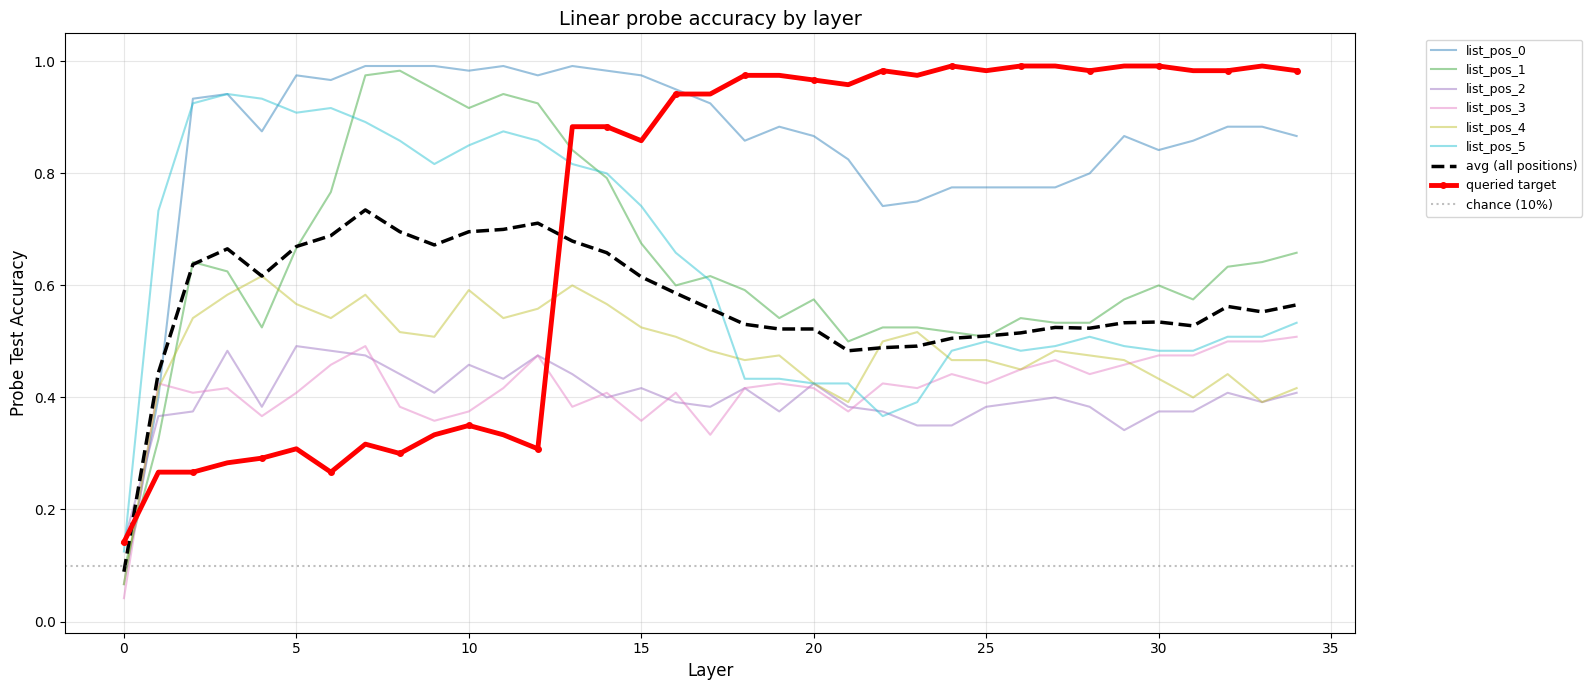

In [47]:
def plot_positional_probes(results, n_layers_total):
    layers = list(range(n_layers_total))

    fig, ax = plt.subplots(figsize=(16, 7))

    # Distinct color for each digit position
    digit_colors = plt.cm.tab10(np.linspace(0, 1, LIST_LENGTH))

    for pos in range(LIST_LENGTH):
        accs = [results[(f"list_pos_{pos}", layer)] for layer in layers]
        ax.plot(layers, accs, color=digit_colors[pos], alpha=0.45,
                linewidth=1.5, label=f"list_pos_{pos}")

    # Average of all position probes – black dashed
    avg_accs = []
    for layer in layers:
        layer_accs = [results[(f"list_pos_{pos}", layer)] for pos in range(LIST_LENGTH)]
        avg_accs.append(np.mean(layer_accs))
    ax.plot(layers, avg_accs, color="black", linewidth=2.5,
            linestyle="--", label="avg (all positions)")

    # Queried target probe – prominent red with markers
    queried_accs = [results[(f"queried_target", layer)] for layer in layers]
    ax.plot(layers, queried_accs, color="red", linewidth=3.5,
            marker="o", markersize=4, markevery=2,
            zorder=10, label="queried target")

    # Chance level
    ax.axhline(y=0.1, color="gray", linestyle=":", alpha=0.5, label="chance (10%)")

    ax.set_xlabel("Layer", fontsize=12)
    ax.set_ylabel("Probe Test Accuracy", fontsize=12)
    ax.set_title("Linear probe accuracy by layer", fontsize=14)
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
    ax.set_ylim(-0.02, 1.05)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

n_layers_total = ft_activations.shape[1]
plot_positional_probes(pos_probe_results, n_layers_total)